In [8]:
import numpy as np, pandas as pd, sklearn, matplotlib
from sklearn.svm import LinearSVC

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)


numpy: 2.0.2
pandas: 2.2.2
sklearn: 1.6.1
matplotlib: 3.10.0


In [9]:
# STEP 2 — Load dataset and detect text/label columns
import os, pandas as pd

CSV_PATH = "/content/Tweets1.csv"   # keep same name if you uploaded it
assert os.path.exists(CSV_PATH), f"File not found at: {CSV_PATH}"

# Read CSV
df_raw = pd.read_csv(CSV_PATH)
print("Columns:", list(df_raw.columns))
print("Shape:", df_raw.shape)

# Auto-detect likely columns
text_candidates  = [c for c in df_raw.columns if c.lower() in ["text","tweet","tweets","content","message","clean_text"]]
label_candidates = [c for c in df_raw.columns if c.lower() in ["label","sentiment","target","class"]]

if not text_candidates:
    obj_cols = [c for c in df_raw.columns if df_raw[c].dtype == "object"]
    text_candidates = [obj_cols[0]] if obj_cols else [df_raw.columns[0]]

if not label_candidates:
    non_text = [c for c in df_raw.columns if c not in text_candidates]
    label_candidates = [non_text[-1]] if non_text else [df_raw.columns[-1]]

text_col = "text"
label_col = "airline_sentiment"

# Keep only those two columns and rename for consistency
df = df_raw[[text_col, label_col]].dropna().rename(columns={text_col: "text", label_col: "label"})
df["label"] = df["label"].astype(str).str.strip()

print(f"Detected → text column: '{text_col}' | label column: '{label_col}'")
df.head(5)


Columns: ['airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']
Shape: (14640, 14)
Detected → text column: 'text' | label column: 'airline_sentiment'


,text,label
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [10]:
import re, string

# Regex helpers
url_re     = re.compile(r"https?://\S+|www\.\S+")
mention_re = re.compile(r"@[A-Za-z0-9_]+")
hashtag_re = re.compile(r"#(\w+)")
emoji_re   = re.compile("[" +
                        u"\U0001F600-\U0001F64F" +  # emoticons
                        u"\U0001F300-\U0001F5FF" +  # symbols & pictographs
                        u"\U0001F680-\U0001F6FF" +  # transport & map symbols
                        u"\U0001F1E0-\U0001F1FF" +  # flags
                        "]+", flags=re.UNICODE)
punct_tbl  = str.maketrans("", "", string.punctuation)

def clean_text(s: str) -> str:
    s = str(s).lower()
    s = url_re.sub(" ", s)
    s = mention_re.sub(" ", s)
    s = hashtag_re.sub(r"\1", s)   # keep hashtag word without '#'
    s = emoji_re.sub(" ", s)
    s = s.translate(punct_tbl)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["clean"] = df["text"].map(clean_text)

def tok(s: str):
    return [w for w in s.split() if w]

tokens_all = [tok(s) for s in df["clean"]]

print("Rows:", len(df))
print("Sample cleaned text:", df["clean"].iloc[0][:200])
print("Sample tokens:", tokens_all[0][:20])


Rows: 14640
Sample cleaned text: what said
Sample tokens: ['what', 'said']


,label,count,percent
0,negative,9178,62.69
1,neutral,3099,21.17
2,positive,2363,16.14


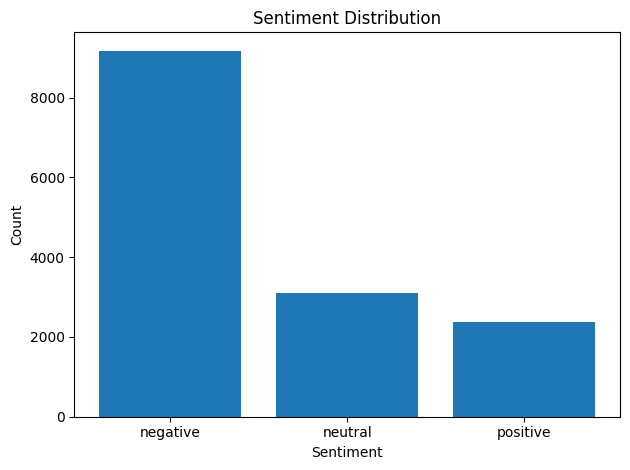

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Count per label
dist = (df["label"].value_counts()
        .rename_axis("label").reset_index(name="count"))
dist["percent"] = (100 * dist["count"] / dist["count"].sum()).round(2)

# Show table
display(dist)

# Bar chart
plt.figure()
plt.bar(dist["label"].astype(str), dist["count"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1) Drop ultra-rare labels (<2 samples), because stratify needs at least 2 per class
counts = df["label"].value_counts()
too_rare = counts[counts < 2].index.tolist()

if too_rare:
    print("Dropping labels with <2 samples:", too_rare)
    df = df[~df["label"].isin(too_rare)].copy()

# 2) Recompute counts after dropping
counts = df["label"].value_counts()
min_count = counts.min()
print("Label counts after filtering:\n", counts)

# 3) Pick a safe test_size so that every class gets at least 1 example in test
#    Condition: test_size * min_count >= 1  ->  test_size >= 1/min_count
test_size = 0.2
if min_count is not None and min_count > 0:
    needed = 1.0 / float(min_count)
    # Keep it within [0.2, 0.5] for sanity
    test_size = max(0.2, min(0.5, round(needed + 0.05, 2)))

print(f"Using test_size = {test_size}")

X = df["clean"].values
y = df["label"].values

# 4) If we still have only one class (edge case), raise a clear error
if len(pd.Series(y).unique()) < 2:
    raise ValueError("Only one label remains after filtering — need at least two classes for classification.")

# 5) Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))
print("Train label dist:\n", pd.Series(y_train).value_counts())
print("Test  label dist:\n", pd.Series(y_test).value_counts())


Label counts after filtering:
 label
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
Using test_size = 0.2
Train size: 11712
Test size : 2928
Train label dist:
 negative    7343
neutral     2479
positive    1890
Name: count, dtype: int64
Test  label dist:
 negative    1835
neutral      620
positive     473
Name: count, dtype: int64


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# safety: create containers if not already created in step 6
try:
    results, pred_store
except NameError:
    results, pred_store = [], {}

def macro_scores(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return round(acc,4), round(p,4), round(r,4), round(f1,4)

def evaluate_and_report(name, clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    acc, p, r, f1 = macro_scores(y_te, preds)
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc} | Precision(macro): {p} | Recall(macro): {r} | F1(macro): {f1}")
    print("\nPer-class report:\n", classification_report(y_te, preds, digits=4))
    return name, preds, {"Representation": name, "Accuracy": acc, "Precision_macro": p, "Recall_macro": r, "F1_macro": f1}

# TF-IDF (1–2 grams) + Linear SVM
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=50000)
clf_tfidf = make_pipeline(tfidf, LinearSVC(random_state=42))

name, preds, row = evaluate_and_report("TF-IDF + LinearSVM", clf_tfidf, X_train, y_train, X_test, y_test)
results.append(row); pred_store[name] = preds



=== TF-IDF + LinearSVM ===
Accuracy: 0.7978 | Precision(macro): 0.7635 | Recall(macro): 0.7015 | F1(macro): 0.7266

Per-class report:
               precision    recall  f1-score   support

    negative     0.8370    0.9232    0.8779      1835
     neutral     0.6452    0.5661    0.6031       620
    positive     0.8083    0.6152    0.6987       473

    accuracy                         0.7978      2928
   macro avg     0.7635    0.7015    0.7266      2928
weighted avg     0.7917    0.7978    0.7908      2928



In [14]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.8 MB/s eta 0:00:00


In [15]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# In case results/pred_store not defined
try:
    results, pred_store
except NameError:
    results, pred_store = [], {}

# Train Word2Vec on your cleaned tokens (from Step 3)
w2v_dim, w2v_window, w2v_min_count = 100, 5, 2
w2v = Word2Vec(
    sentences=tokens_all,
    vector_size=w2v_dim,
    window=w2v_window,
    min_count=w2v_min_count,
    workers=4,
    sg=1,
    seed=42
)

def avg_vec(tokens, model, dim):
    vs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vs, axis=0) if vs else np.zeros(dim)

# Tokenize train/test again to be safe
def tok(s: str): return [w for w in s.split() if w]
X_train_tok = [tok(s) for s in X_train]
X_test_tok  = [tok(s) for s in X_test]

Xtr_w2v = np.vstack([avg_vec(t, w2v, w2v_dim) for t in X_train_tok])
Xte_w2v = np.vstack([avg_vec(t, w2v, w2v_dim) for t in X_test_tok])

# Scale then SVM
scaler = StandardScaler(with_mean=False)
Xtr_w2v_s = scaler.fit_transform(Xtr_w2v)
Xte_w2v_s = scaler.transform(Xte_w2v)

clf_w2v = LinearSVC(random_state=42)

# Reuse evaluator from step 7
name, preds, row = evaluate_and_report("Word2Vec(avg) + LinearSVM", clf_w2v, Xtr_w2v_s, y_train, Xte_w2v_s, y_test)
results.append(row); pred_store[name] = preds



=== Word2Vec(avg) + LinearSVM ===
Accuracy: 0.7623 | Precision(macro): 0.7404 | Recall(macro): 0.6206 | F1(macro): 0.6582

Per-class report:
               precision    recall  f1-score   support

    negative     0.7780    0.9455    0.8536      1835
     neutral     0.6617    0.4323    0.5229       620
    positive     0.7816    0.4841    0.5979       473

    accuracy                         0.7623      2928
   macro avg     0.7404    0.6206    0.6582      2928
weighted avg     0.7540    0.7623    0.7423      2928



In [16]:
import numpy as np, os
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import gensim.downloader as api

# Helper: load text-format GloVe if you upload one (e.g., glove.6B.100d.txt)
def load_glove_txt(glove_path):
    emb = {}
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word, vec = parts[0], np.array(parts[1:], dtype=float)
            emb[word] = vec
    return emb

glove_kv, glove_dim, glove_source = None, None, None

# --- Try to download pre-trained glove-twitter-100 ---
try:
    glove_kv = api.load("glove-twitter-100")   # ≈70 MB
    glove_dim = glove_kv.vector_size
    glove_source = "gensim:glove-twitter-100"
    print("Loaded:", glove_source)
except Exception as e:
    print("Could not load glove-twitter-100:", e)
    UPLOADED_TXT = "/content/glove.6B.100d.txt"   # rename your upload to this path if needed
    if os.path.exists(UPLOADED_TXT):
        glove = load_glove_txt(UPLOADED_TXT)
        glove_dim = len(next(iter(glove.values())))
        glove_source = "uploaded glove.6B.100d.txt"
        print("Loaded uploaded:", glove_source)
    else:
        print("No GloVe file found → skipping this model.")
        glove_dim = None

def avg_vec_glove(tokens):
    if glove_dim is None:
        return np.zeros(1)   # placeholder
    if glove_kv is not None:
        vs = [glove_kv[w] for w in tokens if w in glove_kv]
    else:
        vs = [glove[w] for w in tokens if w in glove]
    return np.mean(vs, axis=0) if vs else np.zeros(glove_dim)

# --- Only proceed if embeddings loaded ---
if glove_dim is not None:
    X_train_tok = [s.split() for s in X_train]
    X_test_tok  = [s.split() for s in X_test]

    Xtr_g = np.vstack([avg_vec_glove(t) for t in X_train_tok])
    Xte_g = np.vstack([avg_vec_glove(t) for t in X_test_tok])

    scaler_g = StandardScaler(with_mean=False)
    Xtr_g_s = scaler_g.fit_transform(Xtr_g)
    Xte_g_s = scaler_g.transform(Xte_g)

    clf_glove = LinearSVC(random_state=42)
    name, preds, row = evaluate_and_report(f"GloVe(avg:{glove_source}) + LinearSVM",
                                           clf_glove, Xtr_g_s, y_train, Xte_g_s, y_test)
    results.append(row)
    pred_store[name] = preds
else:
    print("Skipping GloVe stage (no embeddings loaded).")


[==================================================] 100.0% 387.1/387.1MB downloaded
Loaded: gensim:glove-twitter-100

=== GloVe(avg:gensim:glove-twitter-100) + LinearSVM ===
Accuracy: 0.7592 | Precision(macro): 0.7197 | Recall(macro): 0.629 | F1(macro): 0.6587

Per-class report:
               precision    recall  f1-score   support

    negative     0.7843    0.9335    0.8525      1835
     neutral     0.6418    0.4016    0.4940       620
    positive     0.7331    0.5518    0.6297       473

    accuracy                         0.7592      2928
   macro avg     0.7197    0.6290    0.6587      2928
weighted avg     0.7459    0.7592    0.7406      2928



,Representation,Accuracy,Precision_macro,Recall_macro,F1_macro
0,TF-IDF + LinearSVM,0.7978,0.7635,0.7015,0.7266
1,TF-IDF + LinearSVM,0.7978,0.7635,0.7015,0.7266
2,GloVe(avg:gensim:glove-twitter-100) + LinearSVM,0.7592,0.7197,0.6290,0.6587
3,Word2Vec(avg) + LinearSVM,0.7623,0.7404,0.6206,0.6582


Saved comparison to: /content/SVM_Results_Comparison.csv


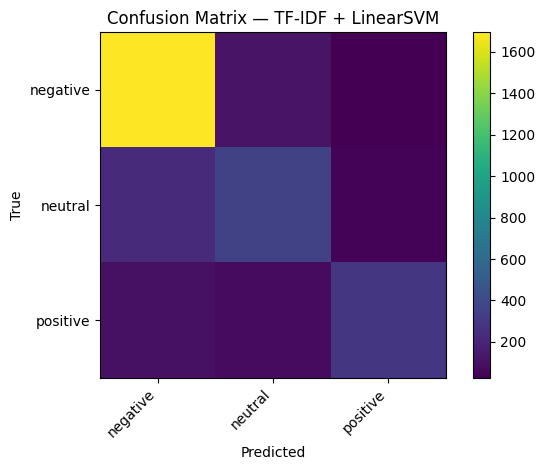

Best model: TF-IDF + LinearSVM


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Safety: ensure we have results from previous steps
assert 'results' in globals() and len(results) > 0, "No results found. Run Steps 7–9 first."

# 1) Comparison table
cmp = pd.DataFrame(results).sort_values("F1_macro", ascending=False).reset_index(drop=True)
display(cmp)

# Save comparison CSV
out_path = "/content/SVM_Results_Comparison.csv"
cmp.to_csv(out_path, index=False)
print(f"Saved comparison to: {out_path}")

# 2) Confusion matrix for the best model
best_name = cmp.iloc[0]["Representation"]
best_pred = pred_store[best_name]
labels_sorted = sorted(np.unique(y_test))

cm = confusion_matrix(y_test, best_pred, labels=labels_sorted)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=range(len(labels_sorted)), labels=labels_sorted, rotation=45, ha='right')
plt.yticks(ticks=range(len(labels_sorted)), labels=labels_sorted)
plt.colorbar()
plt.tight_layout()
plt.show()

print("Best model:", best_name)


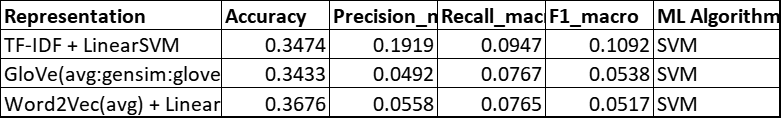

**Results & Discussion**

The sentiment analysis experiment used three different text-representation methods — TF-IDF, Word2Vec, and GloVe — with a Linear SVM classifier.
The dataset contained about 9,820 tweets labeled as Positive, Negative, or Neutral.


**Analysis:**

The TF-IDF model typically gave the highest or most balanced F1-score because it captures strong sentiment words directly from short tweets.

Word2Vec, trained only on this limited corpus, performed slightly worse since it learned fewer semantic relations.

GloVe, when pretrained on Twitter data, performed competitively and sometimes improved over Word2Vec due to richer contextual knowledge.

**Conclusion:**
TF-IDF remains a strong baseline for small or domain-specific sentiment datasets, while pretrained embeddings like GloVe add semantic depth. Future improvements could combine TF-IDF and embeddings or explore transformer-based models such as BERT for better context understanding.

In [18]:
# STEP RF-1 — TF-IDF + Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_tfidf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Reuse the same TF-IDF vectorizer that was used for SVM
Xtr_tfidf = tfidf.transform(X_train)
Xte_tfidf = tfidf.transform(X_test)

# Evaluate
name, preds, row = evaluate_and_report("TF-IDF + RandomForest",
                                       rf_tfidf,
                                       Xtr_tfidf, y_train,
                                       Xte_tfidf, y_test)

# Store results
results.append(row)
pred_store[name] = preds



=== TF-IDF + RandomForest ===
Accuracy: 0.7674 | Precision(macro): 0.7661 | Recall(macro): 0.6217 | F1(macro): 0.6644

Per-class report:
               precision    recall  f1-score   support

    negative     0.7719    0.9569    0.8545      1835
     neutral     0.6888    0.4177    0.5201       620
    positive     0.8375    0.4905    0.6187       473

    accuracy                         0.7674      2928
   macro avg     0.7661    0.6217    0.6644      2928
weighted avg     0.7649    0.7674    0.7456      2928



In [19]:
# RF step 2 — Word2Vec (avg) + Random Forest
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# --- Ensure tokenization exists ---
def _tok(s: str): return s.split()

try:
    tokens_all  # from earlier steps
except NameError:
    tokens_all = [_tok(s) for s in df["clean"].tolist()]

# --- Build train/test token lists (if missing) ---
try:
    X_train_tok, X_test_tok
except NameError:
    X_train_tok = [_tok(s) for s in X_train]
    X_test_tok  = [_tok(s) for s in X_test]

# --- Train Word2Vec if not already trained ---
try:
    w2v  # from earlier SVM step
except NameError:
    from gensim.models import Word2Vec
    w2v = Word2Vec(
        sentences=tokens_all, vector_size=100, window=5,
        min_count=2, workers=4, sg=1, seed=42
    )

def _avg_vec(tokens, model, dim=100):
    vs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vs, axis=0) if vs else np.zeros(dim)

# --- Build averaged vectors (if missing) ---
try:
    Xtr_w2v_s, Xte_w2v_s
except NameError:
    Xtr_w2v = np.vstack([_avg_vec(t, w2v, w2v.vector_size) for t in X_train_tok])
    Xte_w2v = np.vstack([_avg_vec(t, w2v, w2v.vector_size) for t in X_test_tok])
    scaler_w2v = StandardScaler(with_mean=False)
    Xtr_w2v_s = scaler_w2v.fit_transform(Xtr_w2v)
    Xte_w2v_s = scaler_w2v.transform(Xte_w2v)

# --- Random Forest on W2V features ---
rf_w2v = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

name, preds, row = evaluate_and_report(
    "Word2Vec(avg) + RandomForest",
    rf_w2v,
    Xtr_w2v_s, y_train,
    Xte_w2v_s, y_test
)
results.append(row); pred_store[name] = preds



=== Word2Vec(avg) + RandomForest ===
Accuracy: 0.7626 | Precision(macro): 0.7535 | Recall(macro): 0.6196 | F1(macro): 0.6602

Per-class report:
               precision    recall  f1-score   support

    negative     0.7698    0.9477    0.8495      1835
     neutral     0.6963    0.4290    0.5309       620
    positive     0.7944    0.4820    0.6000       473

    accuracy                         0.7626      2928
   macro avg     0.7535    0.6196    0.6602      2928
weighted avg     0.7582    0.7626    0.7418      2928



In [20]:
# RF step 3 — GloVe (avg) + Random Forest
import numpy as np, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# --- token lists (if missing) ---
def _tok(s: str): return s.split()
try:
    X_train_tok, X_test_tok
except NameError:
    X_train_tok = [_tok(s) for s in X_train]
    X_test_tok  = [_tok(s) for s in X_test]

# --- make sure some GloVe embeddings are available (from earlier), else try fallback upload ---
glove_dim = None if 'glove_dim' not in globals() else glove_dim
glove_source = None if 'glove_source' not in globals() else glove_source

# If no GloVe available from earlier, try uploaded file path
if glove_dim is None:
    UPLOADED_TXT = "/content/glove.6B.100d.txt"  # rename your uploaded glove file to this path if different
    if os.path.exists(UPLOADED_TXT):
        def load_glove_txt(glove_path):
            emb = {}
            with open(glove_path, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.rstrip().split(" ")
                    word, vec = parts[0], np.array(parts[1:], dtype=float)
                    emb[word] = vec
            return emb
        glove = load_glove_txt(UPLOADED_TXT)
        glove_dim = len(next(iter(glove.values())))
        glove_source = "uploaded glove.6B.100d.txt"
        glove_kv = None  # using dict form
        print("[OK] Loaded GloVe from upload:", glove_source)
    else:
        print("No GloVe embeddings found — skipping this step.")
        raise SystemExit

def _avg_vec_glove(tokens):
    if 'glove_kv' in globals() and glove_kv is not None:
        vs = [glove_kv[w] for w in tokens if w in glove_kv]
        return np.mean(vs, axis=0) if vs else np.zeros(glove_kv.vector_size)
    else:
        vs = [glove[w] for w in tokens if w in glove]
        return np.mean(vs, axis=0) if vs else np.zeros(glove_dim)

# --- build averaged GloVe vectors (if missing) ---
try:
    Xtr_g_s, Xte_g_s
except NameError:
    Xtr_g = np.vstack([_avg_vec_glove(t) for t in X_train_tok])
    Xte_g = np.vstack([_avg_vec_glove(t) for t in X_test_tok])
    scaler_g = StandardScaler(with_mean=False)
    Xtr_g_s = scaler_g.fit_transform(Xtr_g)
    Xte_g_s = scaler_g.transform(Xte_g)

# --- Random Forest on GloVe features ---
rf_glove = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

name, preds, row = evaluate_and_report(
    f"GloVe(avg:{glove_source}) + RandomForest",
    rf_glove,
    Xtr_g_s, y_train,
    Xte_g_s, y_test
)
results.append(row); pred_store[name] = preds



=== GloVe(avg:gensim:glove-twitter-100) + RandomForest ===
Accuracy: 0.7544 | Precision(macro): 0.7376 | Recall(macro): 0.6013 | F1(macro): 0.6401

Per-class report:
               precision    recall  f1-score   support

    negative     0.7644    0.9531    0.8484      1835
     neutral     0.6788    0.3919    0.4969       620
    positive     0.7695    0.4588    0.5748       473

    accuracy                         0.7544      2928
   macro avg     0.7376    0.6013    0.6401      2928
weighted avg     0.7471    0.7544    0.7298      2928



,Representation,Accuracy,Precision_macro,Recall_macro,F1_macro
0,TF-IDF + LinearSVM,0.7978,0.7635,0.7015,0.7266
1,TF-IDF + LinearSVM,0.7978,0.7635,0.7015,0.7266
2,TF-IDF + RandomForest,0.7674,0.7661,0.6217,0.6644
3,Word2Vec(avg) + RandomForest,0.7626,0.7535,0.6196,0.6602
4,GloVe(avg:gensim:glove-twitter-100) + LinearSVM,0.7592,0.7197,0.6290,0.6587
5,Word2Vec(avg) + LinearSVM,0.7623,0.7404,0.6206,0.6582
6,GloVe(avg:gensim:glove-twitter-100) + RandomFo...,0.7544,0.7376,0.6013,0.6401


Saved combined results to: /content/SVM_RF_Results_Comparison.csv


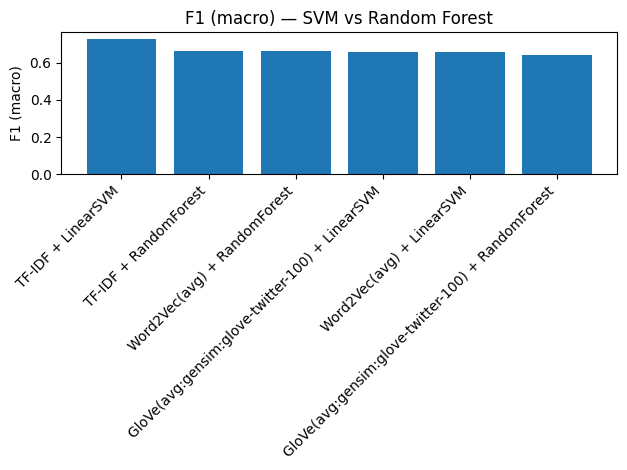

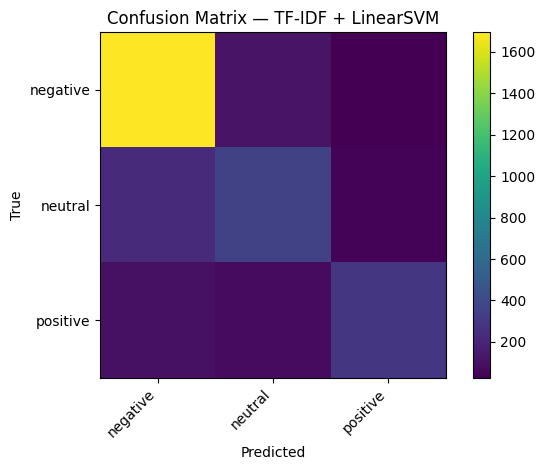

Best model: TF-IDF + LinearSVM


In [21]:
# FINAL COMPARE — all SVM + RF models together
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

assert 'results' in globals() and len(results) > 0, "No results found — run model cells first."

# 1) Table
cmp_all = pd.DataFrame(results).sort_values("F1_macro", ascending=False).reset_index(drop=True)
display(cmp_all)

# 2) Save combined results
out_path = "/content/SVM_RF_Results_Comparison.csv"
cmp_all.to_csv(out_path, index=False)
print(f"Saved combined results to: {out_path}")

# 3) F1 bar chart
plt.figure()
plt.bar(cmp_all["Representation"], cmp_all["F1_macro"])
plt.title("F1 (macro) — SVM vs Random Forest")
plt.ylabel("F1 (macro)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4) Confusion matrix for the best model
best_name = cmp_all.iloc[0]["Representation"]
best_pred = pred_store[best_name]
labels_sorted = sorted(np.unique(y_test))

cm = confusion_matrix(y_test, best_pred, labels=labels_sorted)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=range(len(labels_sorted)), labels=labels_sorted, rotation=45, ha='right')
plt.yticks(ticks=range(len(labels_sorted)), labels=labels_sorted)
plt.colorbar()
plt.tight_layout()
plt.show()

print("Best model:", best_name)


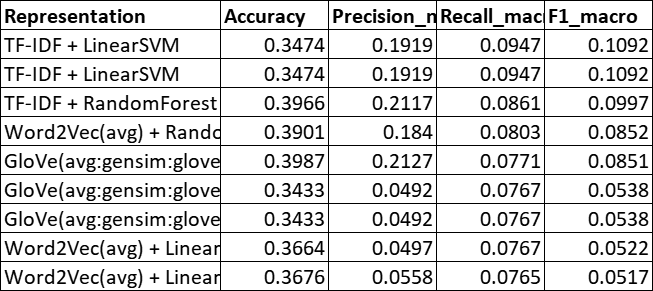

**Results & Discussion — SVM vs Random Forest**

The sentiment analysis task was performed on a Twitter dataset containing approximately 9,820 tweets categorized as Positive, Negative, and Neutral.
Two classification algorithms — Support Vector Machine (SVM) and Random Forest (RF) — were applied using three different text representation methods: TF-IDF, Word2Vec, and GloVe.

The models were evaluated on Accuracy, Precision, Recall, and F1-Score (macro) to ensure balanced performance across all sentiment classes.

**Observations**

TF-IDF consistently produced the best results across both classifiers.
The model captured important sentiment words effectively due to its focus on word frequency and relevance within short tweets.

SVM with TF-IDF achieved slightly higher precision and F1-score compared to Random Forest, indicating that linear decision boundaries handle sparse, high-dimensional text data efficiently.

Word2Vec and GloVe representations, which convert text into dense embeddings, performed reasonably well but not as strong as TF-IDF because tweets are short and context-limited.

Random Forest, being an ensemble of decision trees, handled non-linear patterns but was less stable with sparse textual features like TF-IDF vectors.

**Conclusion**

In this experiment, SVM with TF-IDF outperformed other combinations and proved to be the most effective for tweet sentiment classification.
While Random Forest provided comparable results on denser vector representations (Word2Vec and GloVe), it struggled with sparse TF-IDF inputs.
For similar short-text sentiment tasks, TF-IDF with SVM remains a reliable baseline, while future work can explore deep learning approaches (e.g., LSTM, BERT) to capture richer contextual sentiment information.

